# Resampling, Overfitting & Regularización
**Curso de Modelización — Eduardo Fernández Carrión, PhD**

Contenidos:
1. Generación de números aleatorios y semillas
2. Train/Test Split
3. Cross Validation
4. Otras técnicas: Bootstrap y Jackknife
5. Data Leakage
6. Overfitting
7. Regularización: Ridge, Lasso y Elastic Net

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# sklearn
from sklearn.datasets import make_regression, load_diabetes
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

# statsmodels
import statsmodels.api as sm

print("Libraries loaded OK")

Libraries loaded OK


---
## 1. Generación de Números Aleatorios y Semillas (`seed`)

Muchos algoritmos necesitan generar números aleatorios. Sin fijar una semilla los resultados
cambian en cada ejecución. Con `np.random.seed()` (o `random_state` en sklearn)
garantizamos **reproducibilidad**.

In [ ]:
# Sin semilla: resultados distintos en cada ejecución
print("=== Sin semilla ===")
for _ in range(5):
    print(round(np.random.rand(), 6))

print()

# Con semilla fija dentro del bucle: siempre el mismo número
print("=== Con np.random.seed(10) dentro del bucle ===")
for _ in range(5):
    np.random.seed(10)
    print(round(np.random.rand(), 6))

=== Sin semilla ===
0.199592
0.335892
0.463854
0.161705
0.222054

=== Con np.random.seed(10) dentro del bucle ===
0.771321
0.771321
0.771321
0.771321
0.771321


In [ ]:
# Práctica habitual: fijar la semilla UNA VEZ al principio
  SEED = 42
  np.random.seed(SEED)
  print("Semilla fijada una sola vez (seed=42):")
  print([round(np.random.rand(), 4) for _ in range(5)])

  # En sklearn se usa el parámetro random_state
  X, y = make_regression(n_samples=200, n_features=5, noise=10, random_state=SEED)
  print(f"Dataset: {X.shape[0]} muestras, {X.shape[1]} features (random_state={SEED})")

Semilla fijada una sola vez (seed=42):
[0.3745, 0.9507, 0.732, 0.5987, 0.156]
Dataset: 200 muestras, 5 features (random_state=42)


---
## 2. Train/Test Split

Dividimos el dataset en dos partes: **train** (entrenamiento) y **test** (evaluación).

- Rápido: el modelo se entrena una sola vez.
- La métrica final depende de cómo se hizo la división.
- **Clave**: hacer el corte *antes* de cualquier manipulación de los datos.

In [ ]:
diabetes = load_diabetes()
X_raw = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y_raw = diabetes.target

print(f"Dataset completo: {X_raw.shape[0]} muestras, {X_raw.shape[1]} features")

# Dividir ANTES de cualquier preprocesado
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42
)
print(f"Train: {len(X_train)} muestras  |  Test: {len(X_test)} muestras")

Dataset completo: 442 muestras, 10 features
Train: 353 muestras  |  Test: 89 muestras


=== OLS — Train/Test Split ===
RMSE  Train: 53.56
RMSE  Test:  53.85
R²    Train: 0.5279
R²    Test:  0.4526


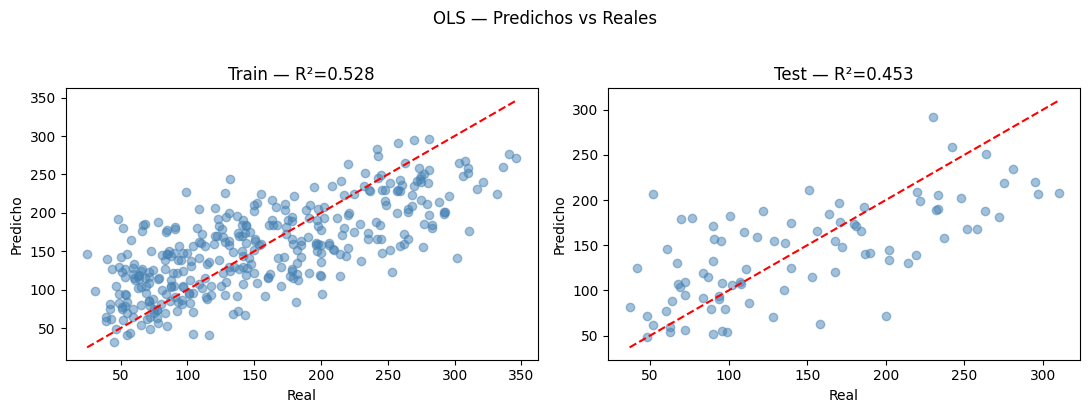

In [ ]:
# Regresión con statsmodels sobre train
X_train_sm = sm.add_constant(X_train)
X_test_sm  = sm.add_constant(X_test)

model_ols = sm.OLS(y_train, X_train_sm).fit()

y_pred_train = model_ols.predict(X_train_sm)
y_pred_test  = model_ols.predict(X_test_sm)

print("=== OLS — Train/Test Split ===")
print(f"RMSE  Train: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.2f}")
print(f"RMSE  Test:  {np.sqrt(mean_squared_error(y_test,  y_pred_test)):.2f}")
print(f"R²    Train: {r2_score(y_train, y_pred_train):.4f}")
print(f"R²    Test:  {r2_score(y_test,  y_pred_test):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, y_true, y_pred, label in zip(
    axes,
    [y_train, y_test],
    [y_pred_train, y_pred_test],
    ["Train", "Test"]
):
    ax.scatter(y_true, y_pred, alpha=0.5, color="steelblue")
    mn = min(y_true.min(), y_pred.min())
    mx = max(y_true.max(), y_pred.max())
    ax.plot([mn, mx], [mn, mx], "r--")
    ax.set_xlabel("Real"); ax.set_ylabel("Predicho")
    ax.set_title(f"{label} — R²={r2_score(y_true, y_pred):.3f}")
plt.suptitle("OLS — Predichos vs Reales", y=1.02)
plt.tight_layout()
plt.show()

---
## 3. Cross Validation (Validación Cruzada)

El dataset se divide en **k folds**. El modelo se entrena con k-1 folds y se evalúa
con el restante, rotando k veces.

- Más robusto frente a particiones sesgadas.
- Requiere k entrenamientos (mayor coste computacional).
- La métrica final se reporta como **media ± desviación típica**.

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Con sklearn
lr = LinearRegression()
cv_r2   = cross_val_score(lr, X_raw, y_raw, cv=kf, scoring="r2")
cv_rmse = np.sqrt(-cross_val_score(lr, X_raw, y_raw, cv=kf,
                                   scoring="neg_mean_squared_error"))

print("=== Cross Validation (k=5) — sklearn ===")
for i, (r2, rmse) in enumerate(zip(cv_r2, cv_rmse), 1):
    print(f"  Fold {i}: R²={r2:.4f}   RMSE={rmse:.2f}")
print(f"Media R²:   {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
print(f"Media RMSE: {cv_rmse.mean():.2f} ± {cv_rmse.std():.2f}")

=== Cross Validation (k=5) — sklearn ===
  Fold 1: R²=0.4526   RMSE=53.85
  Fold 2: R²=0.5732   RMSE=51.60
  Fold 3: R²=0.3914   RMSE=57.55
  Fold 4: R²=0.5843   RMSE=52.90
  Fold 5: R²=0.3908   RMSE=58.34
Media R²:   0.4785 ± 0.0850
Media RMSE: 54.85 ± 2.64


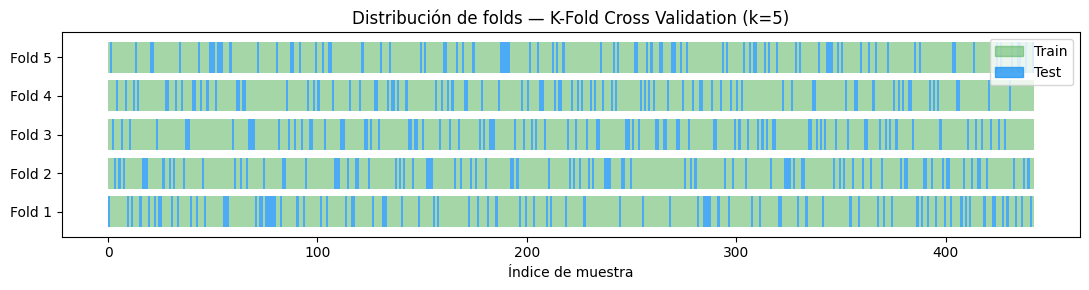

In [ ]:
# Visualización de la distribución de folds
from matplotlib.patches import Patch

n = len(X_raw)
fig, ax = plt.subplots(figsize=(11, 3))

for fold_idx, (train_idx, test_idx) in enumerate(kf.split(X_raw)):
    fold_arr = np.zeros(n)
    fold_arr[test_idx] = 1
    train_ranges = [(i, 1) for i in range(n) if fold_arr[i] == 0]
    test_ranges  = [(i, 1) for i in test_idx]
    ax.broken_barh(train_ranges, (fold_idx - 0.4, 0.8), facecolors="#4CAF50", alpha=0.5)
    ax.broken_barh(test_ranges,  (fold_idx - 0.4, 0.8), facecolors="#2196F3", alpha=0.8)

ax.set_yticks(range(5))
ax.set_yticklabels([f"Fold {i+1}" for i in range(5)])
ax.set_xlabel("Índice de muestra")
ax.set_title("Distribución de folds — K-Fold Cross Validation (k=5)")
ax.legend(handles=[
    Patch(color="#4CAF50", alpha=0.5, label="Train"),
    Patch(color="#2196F3", alpha=0.8, label="Test")
], loc="upper right")
plt.tight_layout()
plt.show()

In [ ]:
# Cross Validation manual con statsmodels
r2_sm = []
for train_idx, test_idx in kf.split(X_raw):
    X_tr_sm = sm.add_constant(X_raw.iloc[train_idx])
    X_te_sm = sm.add_constant(X_raw.iloc[test_idx])
    y_tr_sm = y_raw[train_idx]
    y_te_sm = y_raw[test_idx]

    fit = sm.OLS(y_tr_sm, X_tr_sm).fit()
    r2_sm.append(r2_score(y_te_sm, fit.predict(X_te_sm)))

print("=== Cross Validation manual con statsmodels ===")
for i, r2 in enumerate(r2_sm, 1):
    print(f"  Fold {i}: R²={r2:.4f}")
print(f"Media R²: {np.mean(r2_sm):.4f} ± {np.std(r2_sm):.4f}")

=== Cross Validation manual con statsmodels ===
  Fold 1: R²=0.4526
  Fold 2: R²=0.5732
  Fold 3: R²=0.3914
  Fold 4: R²=0.5843
  Fold 5: R²=0.3908
Media R²: 0.4785 ± 0.0850


---
## 4. Otras Técnicas: Bootstrap y Jackknife

- **Bootstrap**: genera miles de muestras del mismo tamaño con muestreo *con reemplazo*.
  Ideal para calcular intervalos de confianza y la variabilidad de un estimador.
- **Jackknife**: elimina un dato a la vez de forma secuencial. Útil para estimar el sesgo
  de un estimador y su varianza en muestras pequeñas.

=== Bootstrap ===
Media real:            152.13
Media bootstrap:       152.11
IC 95%:                [145.25, 159.76]


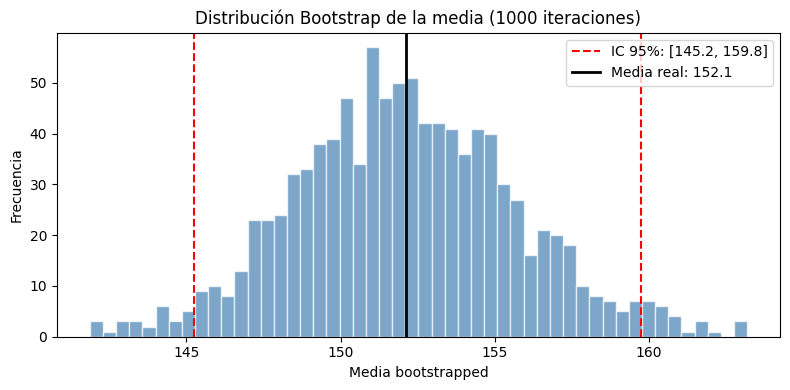

In [ ]:
# Bootstrap
np.random.seed(42)
N_BOOT = 1000
sample = y_raw

boot_means = np.array([
    np.random.choice(sample, size=len(sample), replace=True).mean()
    for _ in range(N_BOOT)
])

ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])
print("=== Bootstrap ===")
print(f"Media real:            {sample.mean():.2f}")
print(f"Media bootstrap:       {boot_means.mean():.2f}")
print(f"IC 95%:                [{ci_low:.2f}, {ci_high:.2f}]")

plt.figure(figsize=(8, 4))
plt.hist(boot_means, bins=50, color="steelblue", alpha=0.7, edgecolor="white")
plt.axvline(ci_low,       color="red",   linestyle="--",
            label=f"IC 95%: [{ci_low:.1f}, {ci_high:.1f}]")
plt.axvline(ci_high,      color="red",   linestyle="--")
plt.axvline(sample.mean(), color="black", linewidth=2,
            label=f"Media real: {sample.mean():.1f}")
plt.xlabel("Media bootstrapped"); plt.ylabel("Frecuencia")
plt.title(f"Distribución Bootstrap de la media ({N_BOOT} iteraciones)")
plt.legend()
plt.tight_layout()
plt.show()

=== Jackknife ===
Estimador original:   142.2200
Sesgo estimado:       0.0000
Varianza estimada:    110.9872
Error estándar:       10.5350


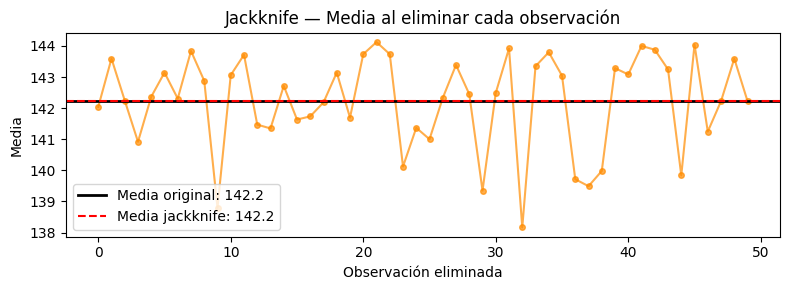

In [ ]:
# Jackknife
sample_small = y_raw[:50]
n_jack = len(sample_small)

jack_means = np.array([
    np.delete(sample_small, i).mean()
    for i in range(n_jack)
])

theta_hat  = sample_small.mean()
theta_jack = jack_means.mean()
bias_jack  = (n_jack - 1) * (theta_jack - theta_hat)
var_jack   = (n_jack - 1) / n_jack * np.sum((jack_means - theta_jack) ** 2)

print("=== Jackknife ===")
print(f"Estimador original:   {theta_hat:.4f}")
print(f"Sesgo estimado:       {bias_jack:.4f}")
print(f"Varianza estimada:    {var_jack:.4f}")
print(f"Error estándar:       {np.sqrt(var_jack):.4f}")

plt.figure(figsize=(8, 3))
plt.plot(jack_means, "o-", color="darkorange", alpha=0.7, markersize=4)
plt.axhline(theta_hat,  color="black", linewidth=2, label=f"Media original: {theta_hat:.1f}")
plt.axhline(theta_jack, color="red",   linestyle="--", label=f"Media jackknife: {theta_jack:.1f}")
plt.xlabel("Observación eliminada"); plt.ylabel("Media")
plt.title("Jackknife — Media al eliminar cada observación")
plt.legend()
plt.tight_layout()
plt.show()

---
## 5. Data Leakage

Ocurre cuando información del conjunto de test se filtra al entrenamiento,
inflando artificialmente las métricas.

| Tipo | Ejemplo |
|---|---|
| Target leakage | Feature no disponible en producción |
| Split tardío | Escalar con stats de todo el dataset antes de dividir |
| Duplicados | El mismo ejemplo en train y test |
| Features del target | Mean encoding calculado con todo el dataset |
| Temporal | Usar datos futuros en series temporales |

In [ ]:
# Demostración: leakage por escalar antes de dividir

# INCORRECTO: ajustar el scaler con TODO el dataset
scaler_bad = StandardScaler()
X_scaled_bad = scaler_bad.fit_transform(X_raw)
X_tr_b, X_te_b, y_tr_b, y_te_b = train_test_split(
    X_scaled_bad, y_raw, test_size=0.2, random_state=42
)
lr_bad  = LinearRegression().fit(X_tr_b, y_tr_b)
r2_bad  = r2_score(y_te_b, lr_bad.predict(X_te_b))

# CORRECTO: dividir primero, escalar solo con train
X_tr_g, X_te_g, y_tr_g, y_te_g = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42
)
scaler_good = StandardScaler()
X_tr_gs = scaler_good.fit_transform(X_tr_g)
X_te_gs = scaler_good.transform(X_te_g)        # aplica la misma transformación
lr_good = LinearRegression().fit(X_tr_gs, y_tr_g)
r2_good = r2_score(y_te_g, lr_good.predict(X_te_gs))

print("=== Impacto del Data Leakage (scaling tardío) ===")
print(f"R² Test con leakage    (INCORRECTO): {r2_bad:.6f}")
print(f"R² Test sin leakage    (CORRECTO):   {r2_good:.6f}")
print(f"Optimismo artificioso:               {r2_bad - r2_good:.6f}")

=== Impacto del Data Leakage (scaling tardío) ===
R² Test con leakage    (INCORRECTO): 0.452603
R² Test sin leakage    (CORRECTO):   0.452603
Optimismo artificioso:               0.000000


In [ ]:
# Forma recomendada: Pipeline (garantiza que el scaler nunca ve test durante fit)
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  LinearRegression())
])

X_tr_p, X_te_p, y_tr_p, y_te_p = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42
)
pipe.fit(X_tr_p, y_tr_p)
r2_pipe = r2_score(y_te_p, pipe.predict(X_te_p))
print(f"Pipeline (recomendado) — R² Test: {r2_pipe:.6f}")

Pipeline (recomendado) — R² Test: 0.452603


---
## 6. Overfitting

El overfitting ocurre cuando el modelo aprende demasiado bien los datos de
entrenamiento (incluyendo el ruido), perdiendo capacidad de generalizar.

> Se detecta cuando las métricas de train y test difieren significativamente.

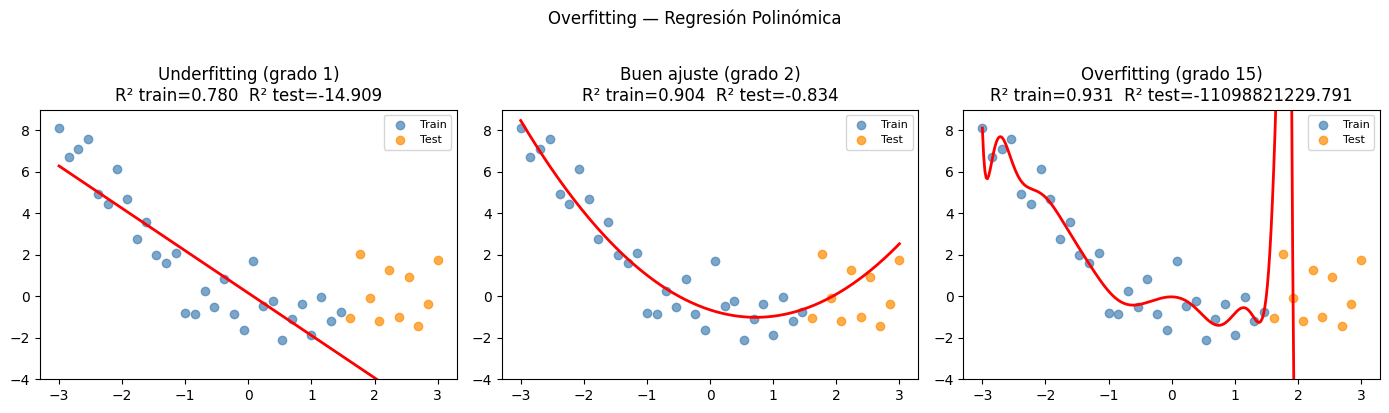

In [ ]:
np.random.seed(42)
n_pts = 40
x_vals = np.linspace(-3, 3, n_pts)
y_vals = 0.5 * x_vals**2 - x_vals + np.random.normal(0, 1.2, n_pts)

x_tr_ov, x_te_ov = x_vals[:30], x_vals[30:]
y_tr_ov, y_te_ov = y_vals[:30], y_vals[30:]
x_fine = np.linspace(-3, 3, 300)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
configs = [(1, "Underfitting (grado 1)"),
           (2, "Buen ajuste (grado 2)"),
           (15, "Overfitting (grado 15)")]

for ax, (degree, title) in zip(axes, configs):
    coeffs  = np.polyfit(x_tr_ov, y_tr_ov, degree)
    poly_fn = np.poly1d(coeffs)
    r2_tr   = r2_score(y_tr_ov, poly_fn(x_tr_ov))
    r2_te   = r2_score(y_te_ov, poly_fn(x_te_ov))
    ax.scatter(x_tr_ov, y_tr_ov, label="Train", color="steelblue", alpha=0.7)
    ax.scatter(x_te_ov, y_te_ov, label="Test",  color="darkorange", alpha=0.7)
    ax.plot(x_fine, np.clip(poly_fn(x_fine), -5, 12), "r-", linewidth=2)
    ax.set_ylim(-4, 9)
    ax.set_title(f"{title}\nR² train={r2_tr:.3f}  R² test={r2_te:.3f}")
    ax.legend(fontsize=8)

plt.suptitle("Overfitting — Regresión Polinómica", y=1.02)
plt.tight_layout()
plt.show()

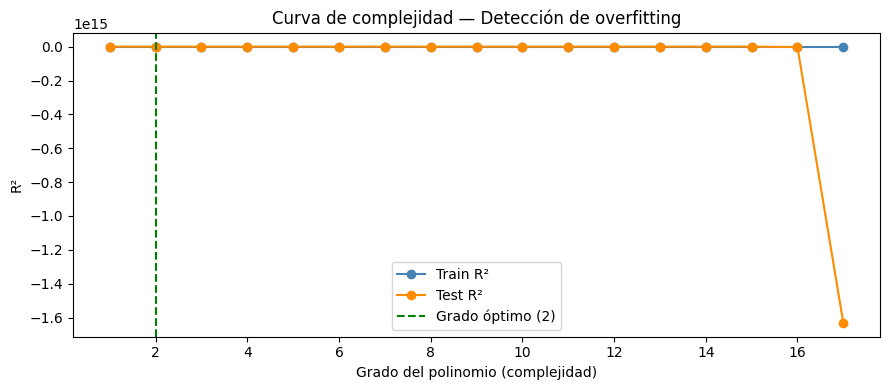

Cuando la brecha entre R² train y R² test crece -> overfitting


In [ ]:
# Curva de complejidad: R² train vs test en función del grado
degrees = range(1, 18)
r2_trs, r2_tes = [], []

for d in degrees:
    c  = np.polyfit(x_tr_ov, y_tr_ov, d)
    fn = np.poly1d(c)
    r2_trs.append(r2_score(y_tr_ov, fn(x_tr_ov)))
    r2_tes.append(r2_score(y_te_ov, fn(x_te_ov)))

plt.figure(figsize=(9, 4))
plt.plot(list(degrees), r2_trs, "o-", color="steelblue",  label="Train R²")
plt.plot(list(degrees), r2_tes, "o-", color="darkorange", label="Test R²")
plt.axvline(2, color="green", linestyle="--", label="Grado óptimo (2)")
plt.xlabel("Grado del polinomio (complejidad)")
plt.ylabel("R²")
plt.title("Curva de complejidad — Detección de overfitting")
plt.legend()
plt.tight_layout()
plt.show()
print("Cuando la brecha entre R² train y R² test crece -> overfitting")

---
## 7. Regularización: Ridge, Lasso y Elastic Net

La regularización añade una penalización a la función de pérdida:

$$\text{Sin regularización:}\quad \min \sum_{i=1}^n (y_i - \hat{y}_i)^2$$

$$\text{Con regularización:}\quad \min \sum_{i=1}^n (y_i - \hat{y}_i)^2 + \lambda \times \text{Complejidad(modelo)}$$

| Método | Penalización | Efecto |
|---|---|---|
| **Ridge (L2)** | $\lambda \sum \beta_j^2$ | Reduce coefs, nunca los elimina |
| **Lasso (L1)** | $\lambda \sum |\beta_j|$ | Fuerza coefs a exactamente 0 → selección de features |
| **Elastic Net** | $\lambda_1 \sum |\beta_j| + \lambda_2 \sum \beta_j^2$ | Combina ambos; ideal con features correlacionadas |

In [ ]:
# Dataset con muchas features (solo 10 de 30 son informativas)
np.random.seed(42)
X_reg, y_reg = make_regression(
    n_samples=150, n_features=30, n_informative=10, noise=20, random_state=42
)

X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    X_reg, y_reg, test_size=0.25, random_state=42
)

scaler_r = StandardScaler()
X_tr_rs  = scaler_r.fit_transform(X_tr_r)
X_te_rs  = scaler_r.transform(X_te_r)

alphas  = [0.001, 0.01, 0.1, 1, 10, 100]
records = []
for alpha in alphas:
    for Model, name in [(Ridge, "Ridge"), (Lasso, "Lasso")]:
        m = Model(alpha=alpha).fit(X_tr_rs, y_tr_r)
        records.append({
            "Modelo": name, "alpha": alpha,
            "R2_train":   r2_score(y_tr_r, m.predict(X_tr_rs)),
            "R2_test":    r2_score(y_te_r, m.predict(X_te_rs)),
            "Coefs_cero": int(np.sum(np.abs(m.coef_) < 1e-3))
        })

df_res = pd.DataFrame(records)
print(df_res.to_string(index=False))

Modelo   alpha  R2_train   R2_test  Coefs_cero
 Ridge   0.001  0.990998  0.961930           0
 Lasso   0.001  0.990998  0.961947           0
 Ridge   0.010  0.990998  0.961937           0
 Lasso   0.010  0.990998  0.962116           0
 Ridge   0.100  0.990997  0.962009           0
 Lasso   0.100  0.990982  0.963836           2
 Ridge   1.000  0.990879  0.962431           0
 Lasso   1.000  0.990027  0.973120          10
 Ridge  10.000  0.982128  0.946620           0
 Lasso  10.000  0.956351  0.917999          21
 Ridge 100.000  0.788452  0.631290           0
 Lasso 100.000  0.002427 -0.037571          29


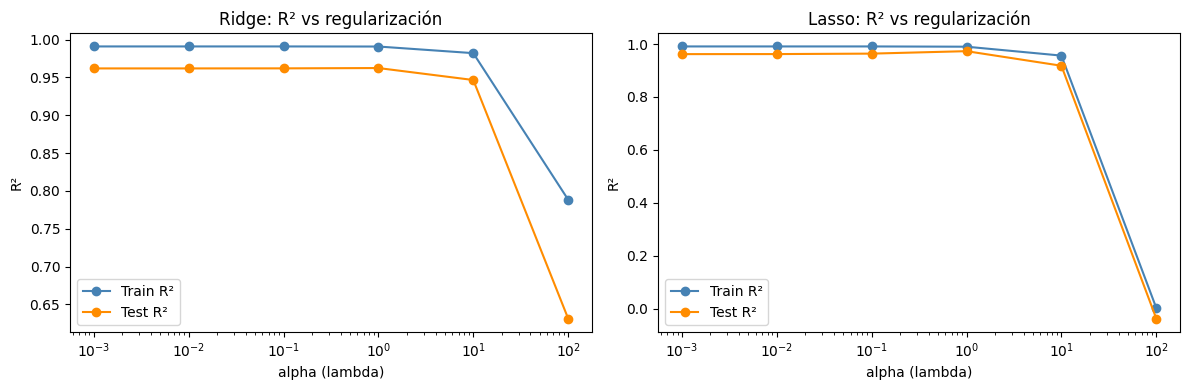

In [ ]:
# R² test vs alpha para Ridge y Lasso
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, name in zip(axes, ["Ridge", "Lasso"]):
    sub = df_res[df_res["Modelo"] == name]
    ax.semilogx(sub["alpha"], sub["R2_train"], "o-", color="steelblue",  label="Train R²")
    ax.semilogx(sub["alpha"], sub["R2_test"],  "o-", color="darkorange", label="Test R²")
    ax.set_xlabel("alpha (lambda)")
    ax.set_ylabel("R²")
    ax.set_title(f"{name}: R² vs regularización")
    ax.legend()
plt.tight_layout()
plt.show()

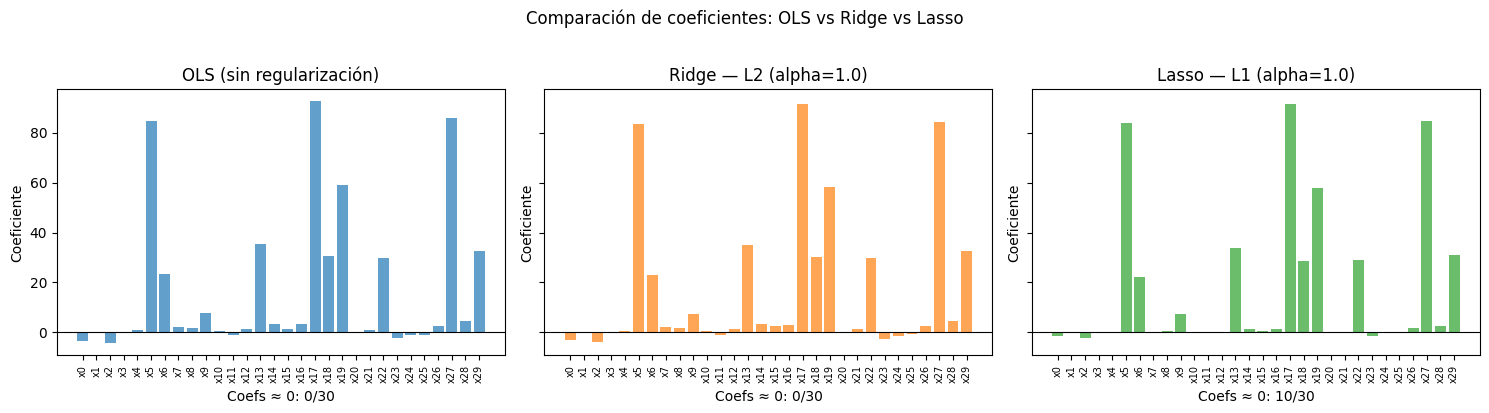

OLS   — coefs≈0: 0
Ridge — coefs≈0: 0  (reduce, no elimina)
Lasso — coefs≈0: 10  (selección de features)


In [ ]:
# Comparación de coeficientes: OLS vs Ridge vs Lasso
ALPHA = 1.0
ols   = LinearRegression().fit(X_tr_rs, y_tr_r)
ridge = Ridge(alpha=ALPHA).fit(X_tr_rs, y_tr_r)
lasso = Lasso(alpha=ALPHA).fit(X_tr_rs, y_tr_r)

labels = [f"x{i}" for i in range(X_reg.shape[1])]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, coef, color, title in zip(
    axes,
    [ols.coef_, ridge.coef_, lasso.coef_],
    ["#1f77b4", "#ff7f0e", "#2ca02c"],
    ["OLS (sin regularización)",
     f"Ridge — L2 (alpha={ALPHA})",
     f"Lasso — L1 (alpha={ALPHA})"]
):
    ax.bar(labels, coef, color=color, alpha=0.7)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticklabels(labels, rotation=90, fontsize=7)
    ax.set_title(title)
    ax.set_ylabel("Coeficiente")
    n_zero = int(np.sum(np.abs(coef) < 1e-3))
    ax.set_xlabel(f"Coefs ≈ 0: {n_zero}/{len(labels)}")

plt.suptitle("Comparación de coeficientes: OLS vs Ridge vs Lasso", y=1.02)
plt.tight_layout()
plt.show()

print(f"OLS   — coefs≈0: {int(np.sum(np.abs(ols.coef_)   < 1e-3))}")
print(f"Ridge — coefs≈0: {int(np.sum(np.abs(ridge.coef_) < 1e-3))}  (reduce, no elimina)")
print(f"Lasso — coefs≈0: {int(np.sum(np.abs(lasso.coef_) < 1e-3))}  (selección de features)")

### Elastic Net

Combina L1 y L2 en una sola función de pérdida.
El parámetro `l1_ratio` controla la mezcla: 0 → Ridge puro, 1 → Lasso puro.
Ideal cuando existen **features correlacionadas**.

=== Elastic Net — impacto de l1_ratio (alpha=1.0) ===
 l1_ratio  R2_test  Coefs_cero
      0.0 0.602368           0
      0.1 0.629237           1
      0.3 0.690924           0
      0.5 0.765655           0
      0.7 0.853131           2
      0.9 0.945506           7
      1.0 0.973120          10


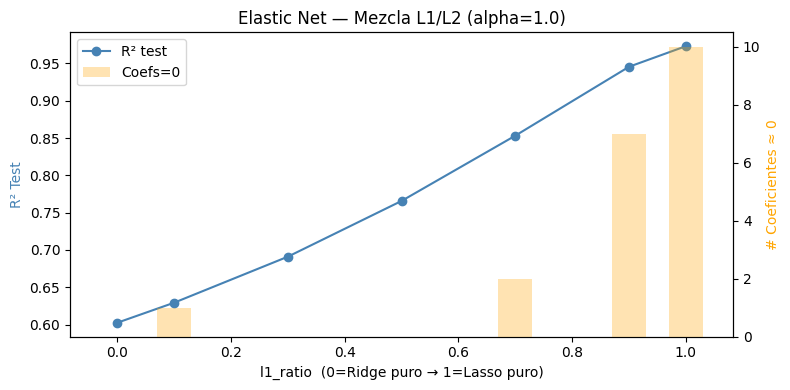

In [ ]:
l1_ratios = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
enet_rows  = []
for ratio in l1_ratios:
    enet = ElasticNet(alpha=1.0, l1_ratio=ratio, max_iter=5000, random_state=42)
    enet.fit(X_tr_rs, y_tr_r)
    enet_rows.append({
        "l1_ratio":   ratio,
        "R2_test":    r2_score(y_te_r, enet.predict(X_te_rs)),
        "Coefs_cero": int(np.sum(np.abs(enet.coef_) < 1e-3))
    })

df_enet = pd.DataFrame(enet_rows)
print("=== Elastic Net — impacto de l1_ratio (alpha=1.0) ===")
print(df_enet.to_string(index=False))

fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()
ax1.plot(df_enet["l1_ratio"], df_enet["R2_test"], "o-", color="steelblue", label="R² test")
ax2.bar(df_enet["l1_ratio"], df_enet["Coefs_cero"],
        alpha=0.3, color="orange", width=0.06, label="Coefs=0")
ax1.set_xlabel("l1_ratio  (0=Ridge puro → 1=Lasso puro)")
ax1.set_ylabel("R² Test", color="steelblue")
ax2.set_ylabel("# Coeficientes ≈ 0", color="orange")
ax1.set_title("Elastic Net — Mezcla L1/L2 (alpha=1.0)")
lines1, lbl1 = ax1.get_legend_handles_labels()
lines2, lbl2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, lbl1 + lbl2, loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
# Regularización con statsmodels (fit_regularized)
X_sm_tr = sm.add_constant(X_tr_rs)
X_sm_te = sm.add_constant(X_te_rs)

model_sm = sm.OLS(y_tr_r, X_sm_tr)

fits = {
    "OLS":        model_sm.fit(),
    "Ridge (L2)": model_sm.fit_regularized(method="elastic_net", alpha=1.0, L1_wt=0.0),
    "Lasso (L1)": model_sm.fit_regularized(method="elastic_net", alpha=1.0, L1_wt=1.0),
    "ElasticNet": model_sm.fit_regularized(method="elastic_net", alpha=1.0, L1_wt=0.5),
}

print("=== Comparación final — statsmodels ===")
print(f"{'Modelo':<14}  {'R² Train':>10}  {'R² Test':>10}  {'Coefs≈0':>8}")
print("-" * 50)
for name, fit in fits.items():
    y_hat_tr = fit.predict(X_sm_tr)
    y_hat_te = fit.predict(X_sm_te)
    r2_tr    = r2_score(y_tr_r, y_hat_tr)
    r2_te    = r2_score(y_te_r, y_hat_te)
    n_zero   = int(np.sum(np.abs(fit.params[1:]) < 1e-3))
    print(f"{name:<14}  {r2_tr:>10.4f}  {r2_te:>10.4f}  {n_zero:>8}")

=== Comparación final — statsmodels ===
Modelo            R² Train     R² Test   Coefs≈0
--------------------------------------------------
OLS                 0.9910      0.9619         0
Ridge (L2)          0.7655      0.5999         0
Lasso (L1)          0.9897      0.9738        13
ElasticNet          0.8790      0.7641         0


---
## Resumen

| Concepto | Clave |
|---|---|
| **Seed** | Fijar `random_state` para reproducibilidad |
| **Train/Test split** | Rápido; dividir *antes* de preprocesar |
| **Cross Validation** | Robusto; reportar media ± std |
| **Bootstrap** | IC de estimadores; muestreo *con* reemplazo |
| **Jackknife** | Sesgo y varianza; elimina un dato a la vez |
| **Data leakage** | Usar `Pipeline`; dividir antes de escalar |
| **Overfitting** | Brecha train/test; reducir complejidad o regularizar |
| **Ridge (L2)** | Reduce coefs, nunca los elimina |
| **Lasso (L1)** | Pone coefs a cero → selección de features |
| **Elastic Net** | Combina L1+L2; ideal con features correlacionadas |